# Data pre-processing
## Tokenization
### Before feeding text data into model, we need to split into small parts known as TOKENS
## Vectorization
### After tokenizing data we need to convert to numbers as models does not process plain text
## Imbalanced data
### In data science and machine learning, **imbalanced data** refers to a situation where the number of observations (data points) in different classes of a dataset are not equally distributed. Specifically, one class (or more) has a significantly higher number of instances compared to the other class(es)
### This creates a **majority class** (the one with many observations) and a **minority class** (the one with few observations).
### Why is Imbalanced Data a Problem?

Imbalanced data poses significant challenges for machine learning models, primarily because:

1.  **Model Bias:** Most standard machine learning algorithms are designed to maximize overall accuracy. When trained on imbalanced data, they tend to become biased towards the majority class. They learn to predict the majority class most of the time because it leads to higher overall accuracy.

2.  **Poor Performance on Minority Class:** Consequently, the model will perform very poorly at identifying instances of the minority class. This is often problematic because, in many real-world scenarios, the minority class is the one we are most interested in predicting accurately (e.g., fraud, disease, rare events).

3.  **Misleading Evaluation Metrics:** Traditional accuracy can be highly misleading with imbalanced data.
    *   **Example:** If 99% of your data belongs to Class A and 1% to Class B, a model that simply predicts Class A every single time will achieve 99% accuracy. While statistically high, this model is completely useless for identifying Class B, which might be the critical goal.
    *   More suitable metrics for imbalanced data include **Precision, Recall (Sensitivity), F1-score, ROC AUC, Precision-Recall AUC**, which focus on the performance of individual classes, especially the minority one.

### Common Examples of Imbalanced Data:

*   **Fraud Detection:** The vast majority of transactions are legitimate (majority class), while a tiny fraction are fraudulent (minority class).
*   **Disease Diagnosis:** Most people are healthy (majority class), while only a small percentage have a specific rare disease (minority class).
*   **Spam Detection:** Most emails are not spam (majority class), while a smaller percentage are spam (minority class).
*   **Customer Churn:** Most customers remain loyal (majority class), while a small portion churn (minority class).
*   **Anomaly Detection:** Detecting unusual patterns or outliers, which are inherently rare events.
*   **Rare Event Prediction:** Predicting natural disasters, equipment failures, etc.

### How to Identify Imbalanced Data:

You can easily check for data imbalance by:

*   **Counting Class Frequencies:** Using `value_counts()` in pandas or similar functions to see the number of instances for each class.
*   **Visualizing:** Creating bar plots or pie charts to visually represent class distributions.
*   **Calculating Ratios:** Determining the ratio of the majority class to the minority class (e.g., 100:1, 1000:1).

### Techniques to Handle Imbalanced Data (Briefly):

Addressing imbalanced data is a critical step in building robust models. Common strategies include:

*   **Resampling Techniques:**
    *   **Oversampling:** Increasing the number of instances in the minority class (e.g., by duplicating existing samples, or using synthetic data generation methods like SMOTE - Synthetic Minority Over-sampling Technique).
    *   **Undersampling:** Decreasing the number of instances in the majority class (e.g., by randomly removing samples).
*   **Algorithmic Approaches:**
    *   **Cost-sensitive learning:** Modifying the learning algorithm to penalize misclassifications of the minority class more heavily.
    *   Using algorithms more robust to imbalance (e.g., tree-based methods like Random Forest or XGBoost can sometimes handle it better than linear models).
*   **Ensemble Methods:** Combining multiple models, often with resampling, to improve overall performance.
*   **Changing Evaluation Metrics:** Focusing on metrics like F1-score, Precision, Recall, or ROC AUC instead of just accuracy.




In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix
import string

## row_data = pd.read_csv("user_courses_review_09_2023.csv")
## If we directly use above code and try to read data, we will get errors
## As in data some of the rows having empty columns
## We need to clean the data


In [2]:
#def clean_data():
#    with open("user_courses_review_09_2023.csv") as csvfile:




In [3]:
row_data = pd.read_csv("user_courses_review_09_2023.csv",
                       on_bad_lines="skip",
                       engine="python")
row_data

,course_name,lecture_name,review_rating,review_comment
0,A/B Testing in Python,How to set up the A/B test,5,If she could provide more details about the pr...
1,A/B Testing in Python,How to set up the A/B test,5,nice
2,A/B Testing in Python,How to set up the A/B test,5,excellent course
3,A/B Testing in Python,How to set up the A/B test,5,nice
4,A/B Testing in Python,Conclusion,5,It was an experiential learning process
...,...,...,...,...
10814,Working with Text Files in Python,Working with Text Files - Conclusion,5,This course was very informative and had a lot...
10815,Working with Text Files in Python,Principles of Importing Data in Python,5,On to the point
10816,Working with Text Files in Python,Principles of Importing Data in Python,5,loving it
10817,Working with Text Files in Python,Principles of Importing Data in Python,5,Good course


# Check Data types

In [4]:
data_types_before = row_data.dtypes
#def converting_data_types(input_data):
    # if input_data["review_rating"].dtype == "str" or input_data["review_rating"].dtype == "object" :
    #    input_data["review_rating"] = pd.to_numeric(input_data["review_rating"], errors="coerce")
    # return input_data
if row_data["review_rating"].dtype == "str" or row_data["review_rating"].dtype == "object" :
   row_data["review_rating"] = pd.to_numeric(row_data["review_rating"], errors="coerce")
# row_data_converted = converting_data_types(row_data)
data_types_after = row_data.dtypes
missing_values_before = row_data.isnull().sum()
missing_values_after = data_types_after.isnull().sum()
data_types_before, data_types_after, missing_values_before, missing_values_after

(course_name       str
 lecture_name      str
 review_rating     str
 review_comment    str
 dtype: object,
 course_name           str
 lecture_name          str
 review_rating     float64
 review_comment        str
 dtype: object,
 course_name         0
 lecture_name       10
 review_rating      18
 review_comment    203
 dtype: int64,
 np.int64(0))

# Describe review point

In [5]:
review_rating_describe = row_data["review_rating"].describe()
review_rating_describe

count    10801.000000
mean         4.842885
std          0.521072
min          1.000000
25%          5.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_rating, dtype: float64

# Plot

(array([  48.,   71.,  250.,  792., 9640.]),
 array([1., 2., 3., 4., 5., 6.]),
 <BarContainer object of 5 artists>)

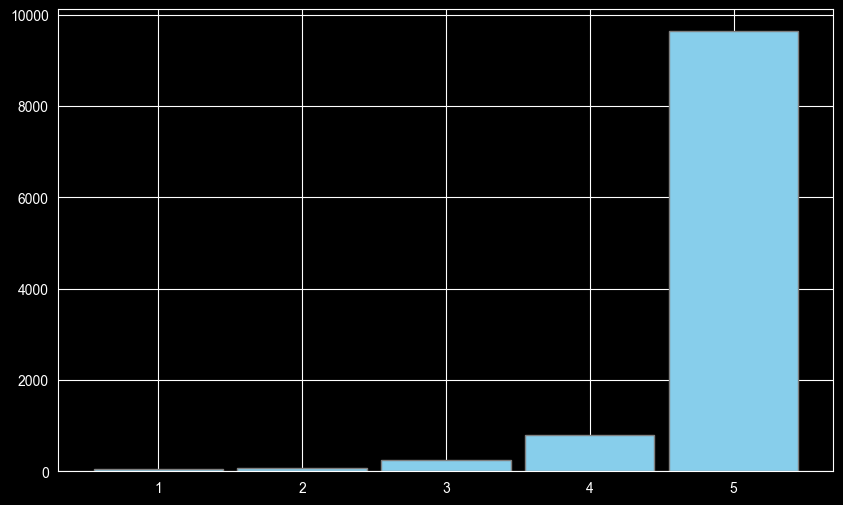

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(row_data['review_rating'].dropna(), bins=range(1, 7), align='left', rwidth=0.9, color='skyblue', edgecolor='gray')

# 4X+2Y-3=0
# 2Y=-4X+3
# y = -2x+3/2

# Clean input data

In [7]:
clean_data = row_data.dropna()
new_shape = clean_data.shape
clean_data["comment_length"] = clean_data["review_comment"].str.len()
correlation = clean_data[['review_rating', 'comment_length']].corr()
correlation

,review_rating,comment_length
review_rating,1.000000,-0.284903
comment_length,-0.284903,1.000000


# Regex to find words

In [8]:
patterns = {
    "positive_emphasis": re.compile(r'\b(great|good|excellent|amazing|love|best|awesome|fantastic)\b', re.IGNORECASE),
    "negative_emphasis": re.compile(r'\b(bad|terrible|awful|poor|worst|hate|disappoint)\b', re.IGNORECASE),
    "question": re.compile(r'\?'),
    "exclamation": re.compile(r'!'),
    "capital_words": re.compile(r'\b[A-Z]{2,}\b')
}
patterns_count = {key : 0 for key in patterns}
for review in clean_data["review_comment"]:
    for key, pattern in patterns.items():
        if re.search(pattern, review):
            patterns_count[key] += 1


patterns_count

{'positive_emphasis': 6134,
 'negative_emphasis': 23,
 'question': 29,
 'exclamation': 1176,
 'capital_words': 531}

# Deep learning

In [11]:
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

clean_data.loc[:, 'review_comment'] = clean_data.loc[:, 'review_comment'].apply(clean_text)
X = clean_data.loc[:,'review_comment']
y = clean_data.loc[:, 'review_comment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
tfidfVectorizer = TfidfVectorizer(stop_words='english')
model = MultinomialNB()
text_clf = make_pipeline(tfidfVectorizer, model)
text_clf.fit(X_train, y_train)
y_predict = text_clf.predict(X_test)
report = classification_report(y_test, y_predict)
conf_matrix = confusion_matrix(y_test, y_predict)
conf_matrix

C:\shiva\coding\python_projects\dear_comrade_data_science_zero_to_hero\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\shiva\coding\python_projects\dear_comrade_data_science_zero_to_hero\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\shiva\coding\python_projects\dear_comrade_data_science_zero_to_hero\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1423, 1423))